In [2]:
import os
import sys
from sys import path
sys.path.append(os.path.expanduser('~/albatros_analysis'))
import numpy as np 
import numba as nb
import time
from scipy import linalg
from scipy import stats
from matplotlib import pyplot as plt
from datetime import datetime as dt
from src.correlations import baseband_data_classes as bdc
from src.utils import baseband_utils as butils
from src.utils import orbcomm_utils as outils
from scripts.xcorr import helper
from scipy.optimize import least_squares
import json
#import extra_functions as ef
import random
#import h5py
from scripts.xcorr import helper as hp
import importlib
from scipy.interpolate import interp1d

BDC is using numpy
BDC is using numpy


In [3]:
#CHECK TO SEE IF THIS MAKES SENSE/IS ALLOWED
def interp_rect(vis):

    #interpolates rectangular form
    t = np.arange(len(vis))
    valid = ~vis.mask

    real_interp = interp1d(t[valid], vis[valid].real, kind='linear', fill_value="extrapolate")
    imag_interp = interp1d(t[valid], vis[valid].imag, kind='linear', fill_value="extrapolate")
    
    vis_interp = real_interp(t) + 1j * imag_interp(t) 
    return vis_interp


def pred(coord1, coord2, start_t, end_t, pulse_idx, channel, satID):
    '''
    predicted phase given satellite
    '''
    bench_time = time.time()
    chunk_len = 30000 * (4096/250e6)
    tle_path = outils.get_tle_file(start_t, "/project/rrg-sievers/mohanagr/OCOMM_TLES")
    pulse_len_s = end_t - start_t
    d = outils.get_sat_delay_new(coord1, coord2, tle_path, start_t, pulse_len_s+1, satID)

    pulse_len_chunks = np.ceil(pulse_len_s / chunk_len)
    pulse_freq = outils.chan2freq(channel, alias=True)

    interp_chunk_times = (np.arange(pulse_len_chunks) * chunk_len)

    #get the delay values for each of these chunks
    delay = np.interp(interp_chunk_times, np.arange(len(d)), d)

    #get the predicted phase at each chunk
    pred = (-delay + delay[0]) * 2 * np.pi * pulse_freq
    print("time taken pred", time.time() - bench_time)

    return pred  

In [4]:
config_path = '/home/thomasb/albatros_analysis/scripts/orbcomm'
config_name = 'config.json'

satdet_path = '/scratch/thomasb'
satdet_name = "pulsedata_1753133403_1757540615.4208999.json"

In [6]:
antennas = []

with open(f"{config_path}/{config_name}", "r") as f:
    config = json.load(f)

    for i, (ant, details) in enumerate(config["antennas"].items()):
        ant_dict = {}
        ant_dict['name'] = details['name']
        ant_dict['coordinates'] = details['coordinates']
        ant_dict['path'] = details['path']

        if i ==0:
            ant_dict['reference'] = 'T'
        else:
            ant_dict['reference'] = 'F'

        antennas.append(ant_dict)

    global_start_time = config["correlation"]["start_timestamp"]
    global_end_time = config["correlation"]["end_timestamp"]
    v_acclen = config["correlation"]["vis_acclen"]
    T_SPECTRA = 4096/250e6
print(antennas)
print("Visibility Accumulation Length", v_acclen)
print(global_start_time)
print(global_end_time)
print(T_SPECTRA)

V_T_ACCLEN = v_acclen* T_SPECTRA
tle_path = outils.get_tle_file(global_start_time, "/project/rrg-sievers/mohanagr/OCOMM_TLES")

print(len(antennas))


antennas[0]['consensus_offset'] = 0
with open(f'{satdet_path}/{satdet_name}') as f:
    pulsedata = json.load(f)
    ants = pulsedata[f'{global_start_time}']
    for i, (ant, details) in enumerate(ants.items()):
        antennas[i+1]['consensus_offset'] = details['consensus_offset']
        antennas[i+1]['pulse_data'] = details['pulse_data']

print(antennas)

[{'name': 'Antenna 1', 'coordinates': [79.41718333333333, -90.76735, 189], 'path': '/scratch/mohanagr/summer_2025/baseband/mars1', 'reference': 'T'}, {'name': 'Antenna 2', 'coordinates': [79.41721666666666, -90.75885, 176], 'path': '/scratch/mohanagr/summer_2025/baseband/mars2', 'reference': 'F'}, {'name': 'Antenna 4', 'coordinates': [79.38846667, -91.01926667, 22], 'path': '/scratch/mohanagr/summer_2025/baseband/mars4', 'reference': 'F'}, {'name': 'Antenna 6', 'coordinates': [79.398, -90.79993333, 43], 'path': '/scratch/mohanagr/summer_2025/baseband/mars6', 'reference': 'F'}, {'name': 'Antenna 7', 'coordinates': [79.41148333, -90.69531667, 26], 'path': '/scratch/mohanagr/summer_2025/baseband/mars7', 'reference': 'F'}, {'name': 'Antenna 8', 'coordinates': [79.44376667, -90.7325, 406], 'path': '/scratch/mohanagr/summer_2025/baseband/mars8', 'reference': 'F'}]
Visibility Accumulation Length 30000
1753133403
1753140603
1.6384e-05
6
[{'name': 'Antenna 1', 'coordinates': [79.41718333333333,

In [7]:
info = antennas[1]
consensus_offset = info['consensus_offset']
print(consensus_offset)
observed_data = {}
desired_pulse_idx = 4

for pulse_idx, p in enumerate(info['pulse_data']):
    
    if pulse_idx != desired_pulse_idx:
        continue
    
    print(f"---------STARTING PULSE {pulse_idx}---------")
    print(p)
    #--------times-----

    relative_start_time = p['start']
    relative_end_time = p['end']
    t_start = global_start_time + relative_start_time
    pulse_len_s = relative_end_time - relative_start_time
    t_end = t_start + pulse_len_s
    pulse_len_chunks = int(np.ceil((pulse_len_s)/(T_SPECTRA * v_acclen)))
    print("rel. start, end t:", relative_start_time, relative_end_time)
    print("global start t:", t_start)
    print("pulse len in s:", pulse_len_s)
    print("pulse len in chunks:", pulse_len_chunks)

    #-------other data--------
    ra_path = antennas[0]['path']
    print(ra_path)
    nra_path = antennas[1]['path']
    print(nra_path)

    #----get initialized information----
    files_a1, idx1 = butils.get_init_info(t_start, t_end, ra_path)
    files_a2, idx2 = butils.get_init_info(t_start, t_end, nra_path)

    #-------set up channels-------
    channels = bdc.get_header(files_a1[0])["channels"].astype('int64')
    chanstart = np.where(channels == 1834)[0][0] 
    chanend = np.where(channels == 1852)[0][0]
    nchans=chanend-chanstart

    #--------call get_avg_fast----------
    time_pulse=time.time()
    pols, rowcounts, channels = hp.get_avg_fast(ra_path, 
                                                nra_path, 
                                                t_start, 
                                                t_end, 
                                                consensus_offset, 
                                                v_acclen, 
                                                pulse_len_chunks, 
                                                chanstart=chanstart, 
                                                chanend=chanend)
    
    pulse_vis = np.empty((pulse_len_chunks, nchans), dtype=np.complex128)
    for i in range(nchans):
        pulse_vis[:, i] = interp_rect(pols[0][:, i])
    
    observed_data[f'{t_start}_{t_end}'] = pulse_vis

    print(f"DONE PULSE {pulse_idx}. TIME:", time.time()-time_pulse)

115507586
---------STARTING PULSE 4---------
{'start': 3400, 'end': 3740, 'sats_present': {'59051': [[1836, 'RELIABLE'], [1837, 'RELIABLE']]}, 'individual_offset': 115507586, 'diff_to_consensus': 0}
rel. start, end t: 3400 3740
global start t: 1753136803
pulse len in s: 340
pulse len in chunks: 692
/scratch/mohanagr/summer_2025/baseband/mars1
/scratch/mohanagr/summer_2025/baseband/mars2
Not reading any data
took 0.100 seconds to read raw data on  /scratch/mohanagr/summer_2025/baseband/mars1/17531/1753136798.raw
took 0.083 seconds to read raw data on  /scratch/mohanagr/summer_2025/baseband/mars2/17531/1753136757.raw
before correction 305176 2807617
after correction 305176 2829846
Starting at:  305176 in filenum:  /scratch/mohanagr/summer_2025/baseband/mars1/17531/1753136798.raw for antenna 1
Starting at:  2829846 in filenum:  /scratch/mohanagr/summer_2025/baseband/mars2/17531/1753136757.raw for antenna 2
ACCLEN RECEIVED IS 30000
took 0.099 seconds to read raw data on  /scratch/mohanagr/

['59051']
3
1837
time for one delay pred: 0.01713728904724121
time taken pred 0.01734447479248047


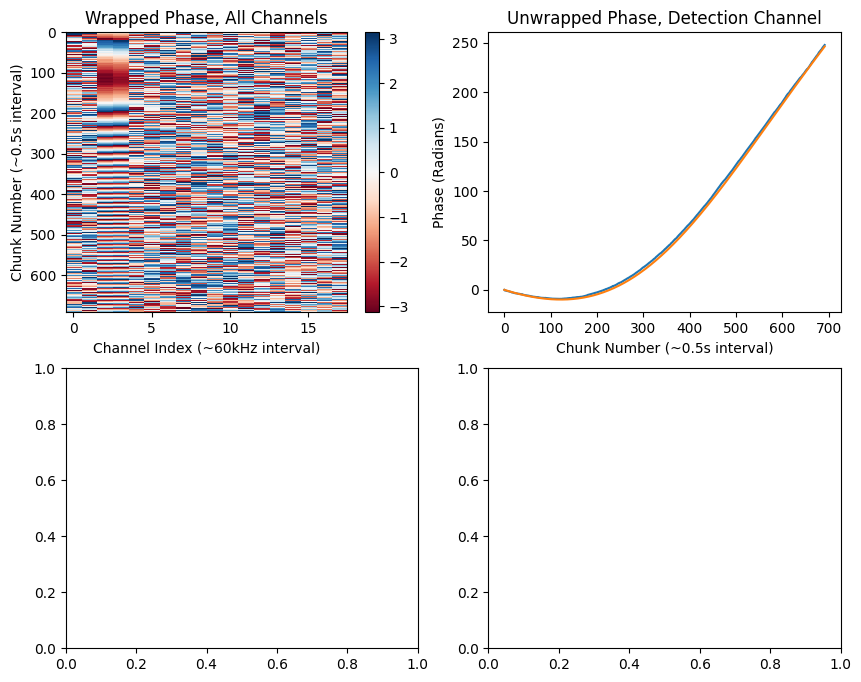

In [8]:
pulse_info = antennas[1]['pulse_data'][desired_pulse_idx]
start, end = pulse_info['start'] + global_start_time, pulse_info['end'] + global_start_time
sats = list(pulse_info['sats_present'].keys())
print(sats)

vis = observed_data[f'{start}_{end}']
p_vis = np.angle(vis)
amp = np.abs(vis)

chanlist = np.arange(1834, 1852)

mean_amp = []
for i in range(18):
    mean_amp.append(np.mean(amp[:,i]))
chan_small_idx = np.where(mean_amp == np.max(mean_amp))[0][0]

print(chan_small_idx)
chanlist = np.arange(1834, 1852)
chan_big_idx = chanlist[chan_small_idx]
print(chan_big_idx)

phase = np.unwrap(p_vis[:,chan_small_idx]) - p_vis[0, chan_small_idx]
diff = np.diff(phase)

for sat in sats:
    bench = 10e9
    pr = pred(antennas[0]['coordinates'],
                antennas[1]['coordinates'],
                start,
                end,
                desired_pulse_idx, 
                chan_big_idx,
                int(sat))[:len(phase)]
    res = np.linalg.norm(phase - pr)
    if res < bench:
        pred_phase = pr

fig, ax = plt.subplots(nrows=2, ncols=2, figsize=(10, 8))
ax[0,0].set_xlabel("Channel Index (~60kHz interval)")
ax[0,0].set_ylabel("Chunk Number (~0.5s interval)")
ax[0,0].set_title("Wrapped Phase, All Channels")
im = ax[0,0].imshow(p_vis, aspect='auto', cmap='RdBu', interpolation="none")
fig.colorbar(im)

ax[0,1].set_xlabel("Chunk Number (~0.5s interval)")
ax[0,1].set_ylabel("Phase (Radians)")
ax[0,1].set_title("Unwrapped Phase, Detection Channel")
ax[0,1].plot(phase)
ax[0,1].plot(pred_phase)


In [7]:
#manually pick what pulse I want to look at
desired_pulse = 4
ant_offsets = []
ant_paths = []

for i, ant in enumerate(antennas):
    ant_offsets.append(ant['consensus_offset'])
    ant_paths.append(ant['path'])

rel_start_t, rel_end_t = antennas[2]['pulse_data'][desired_pulse]['start'], antennas[2]['pulse_data'][desired_pulse]['end']
pulse_start_t = rel_start_t + global_start_time
pulse_end_t = rel_end_t + global_start_time

print('relative start, end t:', rel_start_t, rel_end_t)
print('pulse_duration:', rel_end_t-rel_start_t)

pulse_start_t = rel_start_t + global_start_time
pulse_end_t = rel_end_t + global_start_time

idxs, files = helper.get_init_info_all_ant(pulse_start_t, pulse_end_t, ant_offsets, ant_paths)
pulse_len_chunks = int(np.ceil((pulse_end_t - pulse_start_t)/(T_SPECTRA * v_acclen)))
vis, rowcount, obj = helper.get_avg_fast2(idxs,files,v_acclen,pulse_len_chunks, chanstart,chanend)

relative start, end t: 4585 4815
took 3.188 seconds to read raw data on  /scratch/mohanagr/summer_2025/baseband/mars1/17531/1753137979.raw
took 4.922 seconds to read raw data on  /scratch/mohanagr/summer_2025/baseband/mars2/17531/1753137938.raw
took 13.046 seconds to read raw data on  /scratch/mohanagr/summer_2025/baseband/mars4/17531/1753137967.raw
took 0.972 seconds to read raw data on  /scratch/mohanagr/summer_2025/baseband/mars6/17531/1753137970.raw
took 2.029 seconds to read raw data on  /scratch/mohanagr/summer_2025/baseband/mars7/17531/1753137976.raw
took 0.976 seconds to read raw data on  /scratch/mohanagr/summer_2025/baseband/mars8/17531/1753137979.raw
before correction 549316 3051758
-22228
after correction 549316 3073986
before correction 549316 1281738
-50035
after correction 549316 1331773
before correction 549316 1098633
-83999
after correction 549316 1182632
before correction 549316 732422
-22593
after correction 549316 755015
before correction 549316 549316
-45317
after

NameError: name 'chanstart' is not defined